---
---

# **Employee Burnout Risk: Modeling and Prediction**  
*Authored by Sean Kafka Adhyaksa*

---
---

This notebook moves the employee burnout project into the predictive stage. The project first established which employee, workplace, and text-based conditions appeared most often around different `burnout_risk` patterns. The next goal is to translate those findings into a structured multimodal modeling workflow.

The objective here is not only to pursue the lowest error possible. The modeling process also needs to remain interpretable, technically consistent, and responsible for an HR-style setting. For that reason, this notebook focuses on feature readiness, preprocessing design, multimodal fusion choices, baseline training discipline, and careful evaluation before moving toward inference.

**Key Findings**
1. The final baseline model uses a **multimodal fusion ANN** that combines one prepared tabular input with two lightweight text branches for `feedback_tokens` and `skillset`, making it a coherent baseline for mixed-type burnout prediction.

2. The preprocessing pipeline required careful design before the model could be defined. Target-derived fields were removed, preprocessing was fitted only on the training split, `skillset` had to be parsed correctly from a list-like string, and the text vectorization setup had to be aligned properly with the embedding layers.

3. The final architecture keeps the tabular branch in its prepared form and processes each text branch through `TextVectorization`, `Embedding`, and `GlobalAveragePooling1D` before fusion. This design keeps the model neural but still simple enough to remain explainable and student-level.

4. The model achieved extremely strong test results, with a Test MSE of about `0.000015`, a Test MAE of around `0.0025`, and an `R-squared` score close to `0.9999`. This suggests that the synthetic dataset is highly structured and highly learnable, with the tabular features likely carrying most of the predictive signal.

5. These results should be interpreted carefully because they can be misleading if read too literally. The near-perfect performance does not automatically mean the model is highly robust in a real HR setting. Instead, it more likely reflects how clean, low-noise, and strongly target-recoverable the synthetic dataset is.

**Recommendations**
1. Use the model as a decision-support tool rather than a replacement for HR judgment. Its output is more useful for prioritizing review and follow-up than for making stand-alone employee decisions.

2. Treat the current performance carefully and compare it against simpler baselines, especially a tabular-only model, to check how much the text branches truly add beyond the structured variables.

3. Focus future improvement on robustness, stability, and real-world credibility rather than on chasing even smaller error values inside this synthetic dataset. Repeated runs, noise sensitivity checks, and stronger validation would be more meaningful next steps.

Based on its current performance, the model is best positioned as an early risk-screening baseline rather than a fully automated decision tool. Its strongest value at this stage lies in showing a clean and explainable pipeline while helping identify where employee support and closer review may be needed.

**Model Deployment Demo**  
To demonstrate model inference, the deployed application can be accessed through [**Hugging Face**](https://huggingface.co/spaces/seankafka/Employee-Burnout-Prediction).

---  
# **Introduction**  
---  

## **Case Scenario**

Employee burnout has become an increasingly important issue in modern organizations because it affects not only employee wellbeing, but also productivity, engagement, retention, and the overall quality of work. When pressure accumulates through long working hours, weak support systems, or an unhealthy work rhythm, the impact may appear gradually rather than all at once.

In many companies, burnout is still discussed only after the consequences become visible, such as declining performance, lower participation, disengaged communication, or eventual turnover. That makes burnout difficult to manage if HR relies only on reactive judgment or isolated employee cases.

Because of that, HR needs a more structured analytical view of which signals tend to appear around higher burnout risk. The purpose of this project is not to replace human judgment, but to support it with a clearer evidence base on which employee conditions and workplace patterns deserve closer attention.

## **Problem Statement**

The project has already established the main analytical context for burnout risk. This notebook focuses on the modeling question that follows from that stage: how should the cleaned data be transformed into model-ready inputs without introducing leakage, inconsistent preprocessing, or poorly explained feature choices?

To keep the preparation process transparent, this notebook focuses on a few concrete questions:

1. Which columns should be removed before modeling because they are redundant or derived from the target?

2. How should the dataset be split so that training, validation, and testing remain clearly separated?

3. Are the remaining outliers and missing values serious enough to require treatment before modeling?

4. How should numeric, categorical, feedback text, and skill text be prepared so they can later feed a multimodal model in a consistent way?

## **Project Goals**

1. Continue from the cleaned analysis output and turn it into model-ready inputs.

2. Build reproducible train, validation, and test splits while keeping the workflow leakage-aware.

3. Prepare separate tabular and text branches using preprocessing methods that match each data type.

4. Document each preparation decision clearly so the notebook remains understandable as a student portfolio project.

This notebook does not repeat the full exploratory analysis. Instead, it converts the cleaned dataset into a preparation pipeline that can be reused in the baseline modeling stage. The emphasis here is on clear reasoning, careful feature handling, and smooth transitions between preprocessing steps.

---
# **Dataset Overview**
---

- **Source Dataset**: `BrotherTony/employee-burnout-turnover-prediction-800k`  
- **File Used in This Notebook**: `dataset/cleaned_data.csv`  
- **Working Sample Size**: 80,000 rows  
- **Current Cleaned Columns**: 22  
- **Notebook Scope**: feature engineering, modeling, evaluation, and model saving

This notebook works from the cleaned project dataset rather than from the original wide table. Because of that, the practical data dictionary below reflects the columns that actually enter the modeling workflow, including fields that are later dropped for modeling reasons.

**Working Data Dictionary**

The table below is meant to ground the preprocessing steps that follow. Instead of listing the original raw schema, it summarizes the cleaned columns that are actually used in this notebook.

| Feature Group | Columns | Notes |
|---|---|---|
| Core categorical | `job_level`, `left_company`, `department_group` | Structured labels that will later be one-hot encoded. |
| Numeric employee and score features | `tenure_months`, `salary`, `performance_score`, `satisfaction_score`, `workload_score`, `team_sentiment`, `project_completion_rate`, `overtime_hours`, `training_participation`, `collaboration_score`, `email_sentiment`, `role_complexity_score`, `career_progression_score` | Continuous fields that will later be standardized. |
| Text features | `feedback_tokens`, `skillset` | Two text-oriented fields used in separate branches of the multimodal model. |
| Count-based helper fields | `feedback_token_count`, `skill_count` | Useful as descriptive support, but not kept in the baseline modeling input. |
| Target | `burnout_risk` | Continuous prediction target between 0 and 1. |
| Target-derived label | `burnout_level` | Kept for interpretation only and dropped before modeling to avoid leakage. |

---
# **Quick Recap from Prior [Analysis](1_employee-burnout_analysis.ipynb)**
---

The project has already built the main analytical foundation needed before moving into modeling, so this notebook does not begin from raw employee records. Instead, it starts from a cleaned dataset where the most relevant structured features, grouped department labels, and text-based fields are already easier to read and more suitable for predictive work.

A few findings from the analysis stage matter directly here. First, `burnout_risk` remains the main target because the project is treated as a continuous prediction problem rather than a simple classification task. That means the modeling process should preserve the full range of the target instead of reducing it too early into broad labels.

Therefore, while `burnout_level` was useful for explanation and communication, it should not be used as a model input because it is derived from the target itself, thus eliminated.

The earlier analysis also showed that the remaining features play different roles. Some variables act as direct structured signals, such as workload, satisfaction, overtime, and collaboration-related scores. Others provide supporting context, especially the text-based features from employee feedback and skill profiles. This matters because the modeling stage should not treat all inputs in exactly the same way.

Different feature types need different preprocessing choices before they can be used together in a reasonable model.

At the same time, the cleaned dataset is already quite stable, but it is still not fully model-ready without some additional preparation. A small amount of missing data still remains in `department_group`, some variables still need to be separated into the right preprocessing branches, and the text features need to be transformed into a format that can be learned by the model. So while the major cleaning work is already done, the data still needs one more preparation stage before modeling.

Because of that, this notebook focuses on turning the cleaned analytical dataset into a complete predictive workflow. The goal is not only to train a model, but also to make sure that the feature selection, preprocessing steps, and final architecture remain clear, consistent, and reasonable for a student-level HR project.

---
# **Importing Libraries**  
---  

In [73]:
# standard library
import ast
import json
import pickle
import warnings
from pathlib import Path
from IPython.display import Image, display

# data handling
import pandas as pd
import numpy as np

# visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# feature engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# functional API modeling
import tensorflow as tf
from tensorflow.keras.layers import (
    TextVectorization,
    Input, Dense, Embedding,
    GlobalAveragePooling1D, Concatenate
)
from tensorflow.keras.models import Model

warnings.filterwarnings('ignore')

---  
# **Data Preparation**  
---  

## **Data Loading**

This stage uses the cleaned project dataset stored as `cleaned_data.csv`. Starting from that file keeps the modeling notebook focused on preparation and predictive design rather than repeating raw-data cleanup.

In [74]:
# load the cleaned project dataset
df = pd.read_csv('dataset/cleaned_data.csv')

In [75]:
display(df.head())
print(f'Dataset shape: {df.shape}')

,job_level,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,...,burnout_risk,left_company,role_complexity_score,career_progression_score,department_group,feedback_tokens,feedback_token_count,skillset,skill_count,burnout_level
0,Mid,1,67357.970,0.438385,0.440119,0.482221,0.807898,0.350708,12.820876,0.250061,...,1.000000,Yes,0.2,0.363359,Commercial,management not perfect work small group within...,16,"['CSS3', 'Express.js', 'Machine Learning Theor...",14,High Burnout
1,Mid,44,29704.967,0.495681,0.668779,0.874595,0.701134,0.421464,0.000000,0.372588,...,0.819055,No,0.2,0.751174,Commercial,avoid general hiring hire assign team later es...,25,"['Apache Spark', 'Go', 'AWS', 'Computer Vision...",16,High Burnout
2,Mid,1,62090.816,0.653452,0.257164,0.946794,0.909416,0.591587,0.000000,0.168849,...,0.531163,No,0.2,0.490893,Operations,lot politics within company no real performanc...,18,"['C#', '.NET', 'Python', 'Pandas', 'NumPy', 'S...",20,Medium Burnout
3,Mid,1,139277.100,0.583661,1.000000,0.682500,0.602976,0.579429,0.000000,0.840984,...,0.289379,Yes,0.2,0.815997,R&D,definitely make great career flip burger ann a...,15,"['XGBoost', 'Apache Kafka', 'Ansible', 'Apache...",14,Low Burnout
4,Mid,173,221316.120,0.864410,0.690154,0.619858,0.593657,0.712652,0.000000,0.572924,...,0.845830,Yes,0.2,1.000000,Operations,good environment physically demand easy work f...,42,"['XGBoost', 'Kubernetes', 'CI/CD Pipelines', '...",15,High Burnout


Dataset shape: (80000, 22)


The preview confirms that this notebook is reading the cleaned version of the data rather than the original wide table. At this point the dataframe still contains the target, the target-derived label `burnout_level`, two count-based helper fields, and the two text-oriented columns that will later branch into separate preprocessing paths.

---

## **Overall Info**

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   job_level                 80000 non-null  object 
 1   tenure_months             80000 non-null  int64  
 2   salary                    80000 non-null  float64
 3   performance_score         80000 non-null  float64
 4   satisfaction_score        80000 non-null  float64
 5   workload_score            80000 non-null  float64
 6   team_sentiment            80000 non-null  float64
 7   project_completion_rate   80000 non-null  float64
 8   overtime_hours            80000 non-null  float64
 9   training_participation    80000 non-null  float64
 10  collaboration_score       80000 non-null  float64
 11  email_sentiment           80000 non-null  float64
 12  burnout_risk              80000 non-null  float64
 13  left_company              80000 non-null  object 
 14  role_c

The structure now matches the cleaned dataset used for modeling preparation: 80,000 rows and 22 columns. Most features are already complete, while `department_group` remains the only column with a small amount of missing data.

In [77]:
# summarize missing and non-null values
df_mv = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'non_null_values': df.notna().sum()
})

df_mv[df_mv['missing_values'] > 0]

,missing_values,non_null_values
department_group,99,79901


The missing-value pattern is simple and contained. Only `department_group` contains missing entries, and the count is very small relative to the full dataset. That makes the next handling step fairly lightweight and avoids the need for broad imputation across multiple columns.

---  
# **Feature Engineering**
---

## **Dropping Unneeded Features**

Not every column in the cleaned file should become a model input.

`burnout_level` is removed because it is derived from `burnout_risk`, so keeping it would introduce direct target leakage. The count-based helper columns `feedback_token_count` and `skill_count` are also dropped in this baseline pipeline because the text fields already preserve that information more directly, and keeping both would add unnecessary redundancy at this stage.

In [78]:
# remove target-derived and redundant helper columns before modeling
df.drop(columns=[
    'burnout_level',
    'feedback_token_count',
    'skill_count'
], inplace=True)

print("Dropped columns: ['burnout_level', 'feedback_token_count', 'skill_count']")
print(f'Remaining columns after drop: {df.shape[1]}')

Dropped columns: ['burnout_level', 'feedback_token_count', 'skill_count']
Remaining columns after drop: 19


With those fields removed, the dataset is narrower and better aligned with actual modeling needs. The next step is to separate the target from the candidate input features.

---

## **Splitting The Dataset**

### **1. Splitting X Features and Y Target**

Before building train, validation, and test sets, the target needs to be isolated from the feature matrix. This separation keeps the later preprocessing steps focused only on model inputs while preserving `burnout_risk` as the response variable.

In [79]:
# separate predictors from the regression target
x = df.drop(columns=['burnout_risk'])
y = df['burnout_risk']

print(f'Feature matrix shape: {x.shape}')
print(f'Target shape: {y.shape}')

Feature matrix shape: (80000, 18)
Target shape: (80000,)


### **2. Splitting to Train, Val, and Test Data**

The split is done in two stages. First, a test set is held out and kept untouched for final evaluation. Second, the remaining data is split again to create a validation set. This order keeps the test set fully separate while still giving the model a dedicated validation subset during training.

A fixed `random_state` is used for reproducibility. No stratification is applied here because the target is continuous rather than categorical.

In [80]:
# hold out the final test set first
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.20, random_state=67
)

# split the remaining data into training and validation subsets
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.20, random_state=67
)

# copy each split explicitly before downstream preprocessing steps
x_train = x_train.copy()
x_val = x_val.copy()
x_test = x_test.copy()
y_train = y_train.copy()
y_val = y_val.copy()
y_test = y_test.copy()

print(f'Train Size :  {x_train.shape} ({x_train.shape[0] / len(df):.0%} of rows)')
print(f'Val Size   :  {x_val.shape} ({x_val.shape[0] / len(df):.0%} of rows)')
print(f'Test Size  :  {x_test.shape} ({x_test.shape[0] / len(df):.0%} of rows)')

Train Size :  (51200, 18) (64% of rows)
Val Size   :  (12800, 18) (16% of rows)
Test Size  :  (16000, 18) (20% of rows)


The result is a clear 64% train, 16% validation, and 20% test split. That is a sensible balance for a dataset of this size because the training set remains large, while the validation and test subsets are still big enough to give stable feedback later.

---

## **Outlier Handling Considerations**

In [81]:
def skewness_outliers(dataframe):
    '''
    Return a summary of skewness and simple outlier boundaries
    for each numerical column in a dataframe.
    '''
    num_cols = list(dataframe.select_dtypes(include=np.number).columns)
    list_item = []

    for col in num_cols:
        skew_val = round(dataframe[col].skew(), 2)
        if -0.5 <= skew_val <= 0.5:
            dist_type = 'normal'
        elif -1 <= skew_val <= -0.5 or 0.5 <= skew_val <= 1:
            dist_type = 'moderately skewed'
        else:
            dist_type = 'highly skewed'

        if dist_type == 'normal':
            lower_boundary = round(dataframe[col].mean() - 3 * dataframe[col].std(), 2)
            upper_boundary = round(dataframe[col].mean() + 3 * dataframe[col].std(), 2)
        else:
            iqr = dataframe[col].quantile(0.75) - dataframe[col].quantile(0.25)
            lower_boundary = round(dataframe[col].quantile(0.25) - (iqr * 3), 2)
            upper_boundary = round(dataframe[col].quantile(0.75) + (iqr * 3), 2)

        outlier_count = len(
            dataframe[(dataframe[col] > upper_boundary) | (dataframe[col] < lower_boundary)]
        )
        outlier_pct = round((outlier_count / len(dataframe)) * 100, 2)

        list_item.append([
            col, skew_val, dist_type, lower_boundary, upper_boundary, outlier_count, outlier_pct
        ])

    return pd.DataFrame(
        list_item,
        columns=[
            'column_label', 'skewness', 'distribution',
            'lower_boundary', 'upper_boundary', 'outlier_count', 'outlier_pct'
        ]
    )

In [82]:
# rank the outlier summary so the most notable columns appear first
outlier_summary = skewness_outliers(x_train).sort_values(
    'outlier_pct', ascending=False
).reset_index(drop=True)
outlier_summary

,column_label,skewness,distribution,lower_boundary,upper_boundary,outlier_count,outlier_pct
0,overtime_hours,2.51,highly skewed,-12.02,16.03,2697,5.27
1,role_complexity_score,8.17,highly skewed,0.20,0.20,1071,2.09
2,tenure_months,0.45,normal,-79.76,221.00,125,0.24
3,team_sentiment,-0.46,normal,0.13,1.20,71,0.14
4,performance_score,-0.27,normal,0.14,1.24,19,0.04
5,project_completion_rate,-0.35,normal,0.11,1.08,17,0.03
6,salary,0.75,moderately skewed,-187468.88,345150.38,2,0.00
7,satisfaction_score,-0.10,normal,-0.25,1.41,0,0.00
8,workload_score,-0.29,normal,0.00,1.20,0,0.00
9,training_participation,1.10,highly skewed,-0.79,1.29,0,0.00


The diagnostic shows that most numeric features are not dominated by heavy outlier behavior. Two columns stand out more than the others: `overtime_hours` has the largest outlier share, while `role_complexity_score` is highly skewed because most observations sit at the same lower value and only a small group occupies higher levels.

Even so, aggressive trimming is not applied here. Many of these variables are bounded scores or potentially meaningful risk signals, so removing the upper tail too early could throw away important information. For this baseline pipeline, it is more reasonable to keep the raw values and let scaling handle magnitude differences first.

---

## **Handling Missing Values**

In [83]:
# inspect missing values on the training split only
mv = x_train.isnull().sum()
mv[mv > 0].to_frame(name='missing_values')

,missing_values
department_group,55


The result is still simple: only `department_group` contains missing values, and the count is small. Since this feature is categorical and already represents a grouped label, assigning a separate `Unknown` category is a cleaner choice than forcing these rows into an existing department bucket.

In [84]:
# assign missing grouped departments to an explicit category
x_train['department_group'] = x_train['department_group'].fillna('Unknown')
x_val['department_group'] = x_val['department_group'].fillna('Unknown')
x_test['department_group'] = x_test['department_group'].fillna('Unknown')

print(f"train missing after fill: {x_train['department_group'].isna().sum()}")
print(f"val missing after fill: {x_val['department_group'].isna().sum()}")
print(f"test missing after fill: {x_test['department_group'].isna().sum()}")

train missing after fill: 0
val missing after fill: 0
test missing after fill: 0


---

## **Feature Engineering: Tabular Branch**

The tabular branch handles the structured non-text variables. Numeric columns are scaled, categorical columns are one-hot encoded, and the two outputs are combined into a single dense matrix that can later feed the tabular input branch of the model.

### **1. Scaling Numeric Features**

The first step in the numeric branch is to confirm exactly which columns are treated as numeric features. This keeps the preprocessing transparent and makes it easier to verify that no text or categorical fields accidentally enter the scaling step.

In [85]:
# identify which columns belong to the numeric preprocessing branch
num_cols = x_train.select_dtypes(include='number').columns
print(f'Numeric feature count: {len(num_cols)}')
print('Numeric Features:')
print(num_cols)

Numeric feature count: 13
Numeric Features:
Index(['tenure_months', 'salary', 'performance_score', 'satisfaction_score',
       'workload_score', 'team_sentiment', 'project_completion_rate',
       'overtime_hours', 'training_participation', 'collaboration_score',
       'email_sentiment', 'role_complexity_score', 'career_progression_score'],
      dtype='object')


The list above confirms that 13 columns will enter the numeric preprocessing branch. The next step is to standardize them using `StandardScaler`, which is fitted on `x_train[num_cols]` and then reused to transform `x_val[num_cols]` and `x_test[num_cols]`.

This order is important because the scaler should learn its mean and standard deviation only from the training split. Reusing that fitted transformation on validation and test data keeps the workflow leakage-aware and also makes features with very different numeric ranges, such as `salary` and `performance_score`, more comparable inside the model.

In [86]:
scaler = StandardScaler()

# fit the scaler on training data, then reuse it across the other splits
x_train_num = scaler.fit_transform(x_train[num_cols])
x_val_num = scaler.transform(x_val[num_cols])
x_test_num = scaler.transform(x_test[num_cols])

print(f'Scaled train shape: {x_train_num.shape}')
print(f'Scaled val shape: {x_val_num.shape}')
print(f'Scaled test shape: {x_test_num.shape}')

Scaled train shape: (51200, 13)
Scaled val shape: (12800, 13)
Scaled test shape: (16000, 13)


The output shows that scaling changes the numeric representation, but it does not change the number of rows or the number of numeric columns in each split. In other words, the same 13 numeric features are still present, but they are now expressed on a more comparable scale.

This gives the tabular branch a cleaner starting point before the numeric matrix is later combined with the encoded categorical features.

### **2. Encoding Categorical Features**

Categorical variables need a different treatment because the model cannot work directly with string labels.

One-hot encoding is appropriate here because the number of categories is still manageable, and the variables are nominal rather than ordered in a way that should be expressed numerically.

In [87]:
# keep free-text columns out of the tabular categorical branch
cat_cols = x_train.drop(columns=['feedback_tokens', 'skillset']).select_dtypes(include='object').columns

print(f'Categorical feature count: {len(cat_cols)}')
print('Categorical Features:')
print(cat_cols)

Categorical feature count: 3
Categorical Features:
Index(['job_level', 'left_company', 'department_group'], dtype='object')


The tabular categorical set is intentionally small: `job_level`, `left_company`, and `department_group`. The two text columns are excluded here because they will be modeled separately through text vectorization rather than one-hot expansion.

In [88]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# learn categorical levels on the training data, then apply the same mapping elsewhere
x_train_cat = encoder.fit_transform(x_train[cat_cols])
x_val_cat = encoder.transform(x_val[cat_cols])
x_test_cat = encoder.transform(x_test[cat_cols])

encoded_cat_features = encoder.get_feature_names_out(cat_cols)
print(f'Encoded categorical feature count: {len(encoded_cat_features)}')
print(f'First encoded features: {encoded_cat_features[:10].tolist()}')

Encoded categorical feature count: 16
First encoded features: ['job_level_Entry', 'job_level_Lead', 'job_level_Manager', 'job_level_Mid', 'job_level_Senior', 'left_company_No', 'left_company_Yes', 'department_group_Commercial', 'department_group_Executive', 'department_group_Finance']


### **3. Concatenate Numeric and Categorical Features**

Once both tabular components are prepared, they can be concatenated horizontally into one matrix for each data split. This final tabular representation is what the model will later receive through its structured-data input branch.

In [89]:
# combine the scaled numeric matrix and the encoded categorical matrix
x_train_tab = np.concatenate([x_train_num, x_train_cat], axis=1)
x_val_tab = np.concatenate([x_val_num, x_val_cat], axis=1)
x_test_tab = np.concatenate([x_test_num, x_test_cat], axis=1)

print(f'x_train_tab shape: {x_train_tab.shape}')
print(f'x_val_tab shape: {x_val_tab.shape}')
print(f'x_test_tab shape: {x_test_tab.shape}')

x_train_tab shape: (51200, 29)
x_val_tab shape: (12800, 29)
x_test_tab shape: (16000, 29)


The final tabular branch contains 29 columns in total: 13 scaled numeric features plus 16 encoded categorical features. With the structured branch ready, the next step is to prepare the two text-based inputs.

---

## **Feature Engineering: Text Branch**

The text branch keeps `feedback_tokens` and `skillset` as separate inputs because they describe different aspects of the employee record. `feedback_tokens` captures workplace sentiment and narrative context, while `skillset` describes capability-related information.

One important detail appears here: `feedback_tokens` is already stored as cleaned text, but `skillset` is still stored as a list-like string. That means `skillset` must be parsed first. Without that step, the model would accidentally learn from separated characters instead of actual skill terms.

In [90]:
def parse_skillset_text(value):
    """Convert a list-like skill string into plain text for tokenization."""
    if isinstance(value, list):
        items = value
    elif pd.isna(value):
        return ''
    else:
        try:
            parsed = ast.literal_eval(value)
            items = parsed if isinstance(parsed, list) else [parsed]
        except (ValueError, SyntaxError):
            items = [value]

    return ' '.join(str(item) for item in items)

# feedback text is already stored as cleaned strings
x_train_feedback = x_train['feedback_tokens'].fillna('').astype(str).values
x_val_feedback = x_val['feedback_tokens'].fillna('').astype(str).values
x_test_feedback = x_test['feedback_tokens'].fillna('').astype(str).values

# skill text needs parsing because it is still stored as a list-like string
x_train_skills = x_train['skillset'].apply(parse_skillset_text).values
x_val_skills = x_val['skillset'].apply(parse_skillset_text).values
x_test_skills = x_test['skillset'].apply(parse_skillset_text).values

print('Feedback example:')
print(x_train_feedback[0])
print('\nRaw skillset example:')
print(x_train['skillset'].iloc[0])
print('\nParsed skillset text:')
print(x_train_skills[0])

Feedback example:
serve great well mean approachable regional emea leadership

Raw skillset example:
['PHP', 'Laravel', 'Site Reliability Engineering', 'SRE', 'GCP', 'Go', 'Communication', 'Problem Solving', 'Creativity']

Parsed skillset text:
PHP Laravel Site Reliability Engineering SRE GCP Go Communication Problem Solving Creativity


### **1. Estimating Training Vocabulary and Sequence Length**

Vocabulary size and sequence length are estimated from the training text only. This follows the same logic as the other preprocessing steps: configuration choices should come from the training data, then be reused consistently on validation and test data.

In [91]:
# summarize feedback text from the training split
feedback_tokens = ' '.join(x_train_feedback).split()
feedback_vocab = set(feedback_tokens)

feedback_vocab_size = len(feedback_vocab)
print('feedback vocab:', feedback_vocab_size)

max_feedback_sentence = max(len(text.split()) for text in x_train_feedback)
print('max feedback sentence length:', max_feedback_sentence)

feedback vocab: 3493
max feedback sentence length: 61


The feedback branch has a fairly wide vocabulary, which makes sense because employee comments are more varied and open-ended than the structured features. At the same time, the maximum sequence length remains moderate, so padding these texts later is still manageable.

In [92]:
# summarize parsed skill text from the training split
skills_tokens = ' '.join(x_train_skills).split()
skills_vocab = set(skills_tokens)

skills_vocab_size = len(skills_vocab)
print('skills vocab:', skills_vocab_size)

max_skills_sentence = max(len(text.split()) for text in x_train_skills)
print('max skills length:', max_skills_sentence)

skills vocab: 96
max skills length: 35


The skill branch is much more compact than the feedback branch. That is expected because skill terms repeat more often across employees, even though individual records can still contain fairly long skill lists.

---  
# **Baseline Model: Multimodal Fusion ANN**
---

This baseline model uses a simple multimodal fusion architecture. The tabular input is already standardized and encoded during feature engineering, so it can enter the network as a ready-to-use structured vector. The two text inputs still need their own lightweight neural processing first so raw strings can be converted into fixed-size semantic representations.

The architecture is designed around a practical student-level trade-off. It stays neural enough to model text meaning through embeddings, but it avoids heavier sequence models such as LSTM or transformers so that the pipeline remains explainable and computationally manageable. The main idea is to prepare each modality just enough to become comparable, then let the shared dense layers learn cross-modality burnout patterns after fusion.

---

## **Tabular Branch**

The tabular branch is intentionally kept simple. Because the numeric features have already been scaled and the categorical features have already been one-hot encoded, the tabular matrix is already model-ready. For that reason, this branch does not need a separate dense encoder before fusion.

Leaving the tabular input in its raw prepared form has two advantages in this baseline. First, it avoids compressing the 29 structured features too early. Second, it lets the shared fusion block decide how tabular signals should interact with the two text representations instead of forcing a modality-specific bottleneck first.

In [93]:
# tabular features already form a fixed-size dense matrix
tab_input = Input(shape=(x_train_tab.shape[1],), name='tabular_input')

Unlike the tabular input, both text inputs still begin as raw strings. Each text branch therefore needs a small amount of modality-specific processing before it is ready to join the shared fusion block.

---

## **Text Branch**

The text side of the model stays intentionally lightweight. Each branch uses the same sequence of operations: `TextVectorization -> Embedding -> GlobalAveragePooling1D`.

This pipeline is simple, but still meaningful. `TextVectorization` converts raw text into token ids, `Embedding` learns a dense vector representation for each token, and `GlobalAveragePooling1D` compresses the full sequence into one fixed-size vector. That pooling choice is especially suitable here because the project only needs a compact baseline text encoder, not a full sequence model that emphasizes word order in a highly detailed way.

### **Text Vectorization Setup**

The vectorization layers are defined first because both text branches depend on them. `output_mode='int'` is used so each text sample becomes a sequence of integer token ids that can later be passed into an embedding layer. `output_sequence_length` fixes the sequence size so the model receives tensors with consistent shapes.

A small but important detail is the `max_tokens` setting. The layer internally reserves slots for masking and out-of-vocabulary handling, so the configured vocabulary size is kept slightly larger than the raw vocabulary count. After adaptation, the final vocabulary length is reused as the `input_dim` for the embedding layer so token indices and embedding capacity stay perfectly aligned.

In [94]:
# define the tokenizers used by both text branches
feedback_vectorizer = TextVectorization(
    max_tokens=feedback_vocab_size + 2,
    output_mode='int',
    output_sequence_length=max_feedback_sentence
)

skills_vectorizer = TextVectorization(
    max_tokens=skills_vocab_size + 2,
    output_mode='int',
    output_sequence_length=max_skills_sentence
)

After configuration, both vectorizers are adapted on the training text only. This keeps the text vocabulary consistent with the rest of the preprocessing workflow and prevents validation or test data from influencing the token mapping.

In [95]:
feedback_vectorizer.adapt(x_train_feedback)
skills_vectorizer.adapt(x_train_skills)

The checks below confirm that the text-preparation layers are ready to be used inside the model definition. The final vocabulary sizes will later be reused as the `input_dim` for the corresponding embedding layers, which is safer than relying on the raw vocabulary estimate alone.

In [96]:
feedback_vocab_dim = len(feedback_vectorizer.get_vocabulary())
skills_vocab_dim = len(skills_vectorizer.get_vocabulary())

print(f'Feedback sequence length: {max_feedback_sentence}')
print(f'Feedback embedding input_dim: {feedback_vocab_dim}')
print(f'Skill sequence length: {max_skills_sentence}')
print(f'Skill embedding input_dim: {skills_vocab_dim}')

print('\nParsed feedback example:')
print(x_train_feedback[0])
print('\nParsed skill example:')
print(x_train_skills[0])

Feedback sequence length: 61
Feedback embedding input_dim: 3495
Skill sequence length: 35
Skill embedding input_dim: 98

Parsed feedback example:
serve great well mean approachable regional emea leadership

Parsed skill example:
PHP Laravel Site Reliability Engineering SRE GCP Go Communication Problem Solving Creativity


In [97]:
print('Feedback vocabulary sample:')
print(feedback_vectorizer.get_vocabulary()[:20])

print('\nSkill vocabulary sample:')
print(skills_vectorizer.get_vocabulary()[:20])

Feedback vocabulary sample:
['', '[UNK]', 'work', 'good', 'not', 'great', 'people', 'company', 'pay', 'no', 'get', 'benefit', 'management', 'time', 'place', 'life', 'opportunity', 'lot', 'employee', 'team']

Skill vocabulary sample:
['', '[UNK]', 'teamwork', 'communication', 'resolution', 'mentorship', 'conflict', 'leadership', 'intelligence', 'emotional', 'solving', 'problem', 'time', 'management', 'creativity', 'thinking', 'critical', 'adaptability', 'pipelines', 'learning']


With the text-preparation layers ready, the next step is to define the two text encoders. Each branch receives raw string input, converts it into token ids, maps those ids into dense embeddings, and then compresses the sequence into one fixed-size vector through global average pooling.

Both embedding layers also use `mask_zero=True`. This allows padding tokens to be ignored during pooling, which is why the architecture plot may show small internal nodes such as `not_equal`. Those nodes are expected and simply reflect the masking logic used to prevent padded zeros from being averaged as if they were real tokens.

### **1. Feedback Branch Encoder**

The feedback branch is designed to capture general sentiment and contextual language patterns from employee comments. A 64-dimensional embedding is used here because the feedback vocabulary is broader and noisier than the skill vocabulary, so this branch benefits from a slightly larger representational space.

`GlobalAveragePooling1D` is chosen instead of a recurrent layer because the goal is to summarize the overall tone and token composition of each comment, not to model long sequential dependencies in a highly complex way. That makes the branch easier to train and easier to explain.

In [98]:
# feedback branch: vectorize text, learn token embeddings, then pool to one dense vector
feedback_input = Input(shape=(1,), dtype=tf.string, name='feedback_input')

x_feedback = feedback_vectorizer(feedback_input)
x_feedback = Embedding(
    input_dim=feedback_vocab_dim,
    output_dim=64,
    mask_zero=True,
    name='feedback_embedding'
)(x_feedback)
x_feedback = GlobalAveragePooling1D(name='feedback_pooling')(x_feedback)

### **2. Skillset Branch Encoder**

The skills branch follows the same overall structure, but uses a smaller 32-dimensional embedding because its vocabulary is much narrower and more repetitive than the free-text feedback branch. In this case, the branch mainly needs to encode recurring skill-related terms into a compact vector that can still contribute to the shared prediction stage.

As with the feedback branch, global average pooling is used to keep the encoder simple and to produce a stable fixed-length representation regardless of how many skill tokens appear in a given record.

In [99]:
# skills branch: use the same lightweight text encoder pattern with a smaller embedding space
skills_input = Input(shape=(1,), dtype=tf.string, name='skills_input')

x_skills = skills_vectorizer(skills_input)
x_skills = Embedding(
    input_dim=skills_vocab_dim,
    output_dim=32,
    mask_zero=True,
    name='skills_embedding'
)(x_skills)
x_skills = GlobalAveragePooling1D(name='skills_pooling')(x_skills)

---

## **Fusioning and Dense Layering**

Once the text branches have been converted into fixed-size vectors, they can be fused with the raw tabular input. This concatenation stage is the main multimodal fusion step in the network.

After fusion, two shared dense layers are used to learn interactions across all modalities together. The first dense layer expands the combined representation to 128 units so the model has enough capacity to learn cross-feature interactions after concatenation. The second dense layer compresses that joint representation to 64 units before prediction, which acts as a more compact shared hidden state.

Both dense layers use `ReLU` because it is a practical default for hidden layers in feedforward networks: it is simple, computationally efficient, and helps the model learn non-linear relationships without saturating as quickly as older activations such as sigmoid or tanh. The final output layer uses `sigmoid` because the target is bounded between 0 and 1, so it is helpful for the prediction itself to stay in the same range.

In [100]:
# fuse tabular and text representations, then learn a joint multimodal mapping
combined = Concatenate(name='multimodal_fusion')([tab_input, x_feedback, x_skills])

x_model = Dense(128, activation='relu', name='fusion_dense_1')(combined)
x_model = Dense(64, activation='relu', name='fusion_dense_2')(x_model)
output = Dense(1, activation='sigmoid', name='burnout_risk_output')(x_model)

model_base = Model(
    inputs=[tab_input, feedback_input, skills_input],
    outputs=output,
    name='burnout_multimodal_fusion_ann'
)

---

## **Compile and Finalize Architecture**

The compilation setup is kept intentionally straightforward so the effect of the architecture itself is easier to read. `Adam` is used as the optimizer because it adapts the learning rate during training and usually works well as a strong default for mixed-input neural networks without much tuning. `MSE` is used as the loss because the target is continuous, and larger prediction errors should be penalized more heavily. `MAE` is kept as an additional metric because it is easier to interpret in plain numeric terms than squared error.

Right after compilation, the architecture is visualized with `plot_model()` so the multimodal flow is easier to inspect. If small nodes such as `not_equal` appear in the diagram, they simply represent internal masking operations created by `mask_zero=True` in the embedding layers.

In [101]:
model_base.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

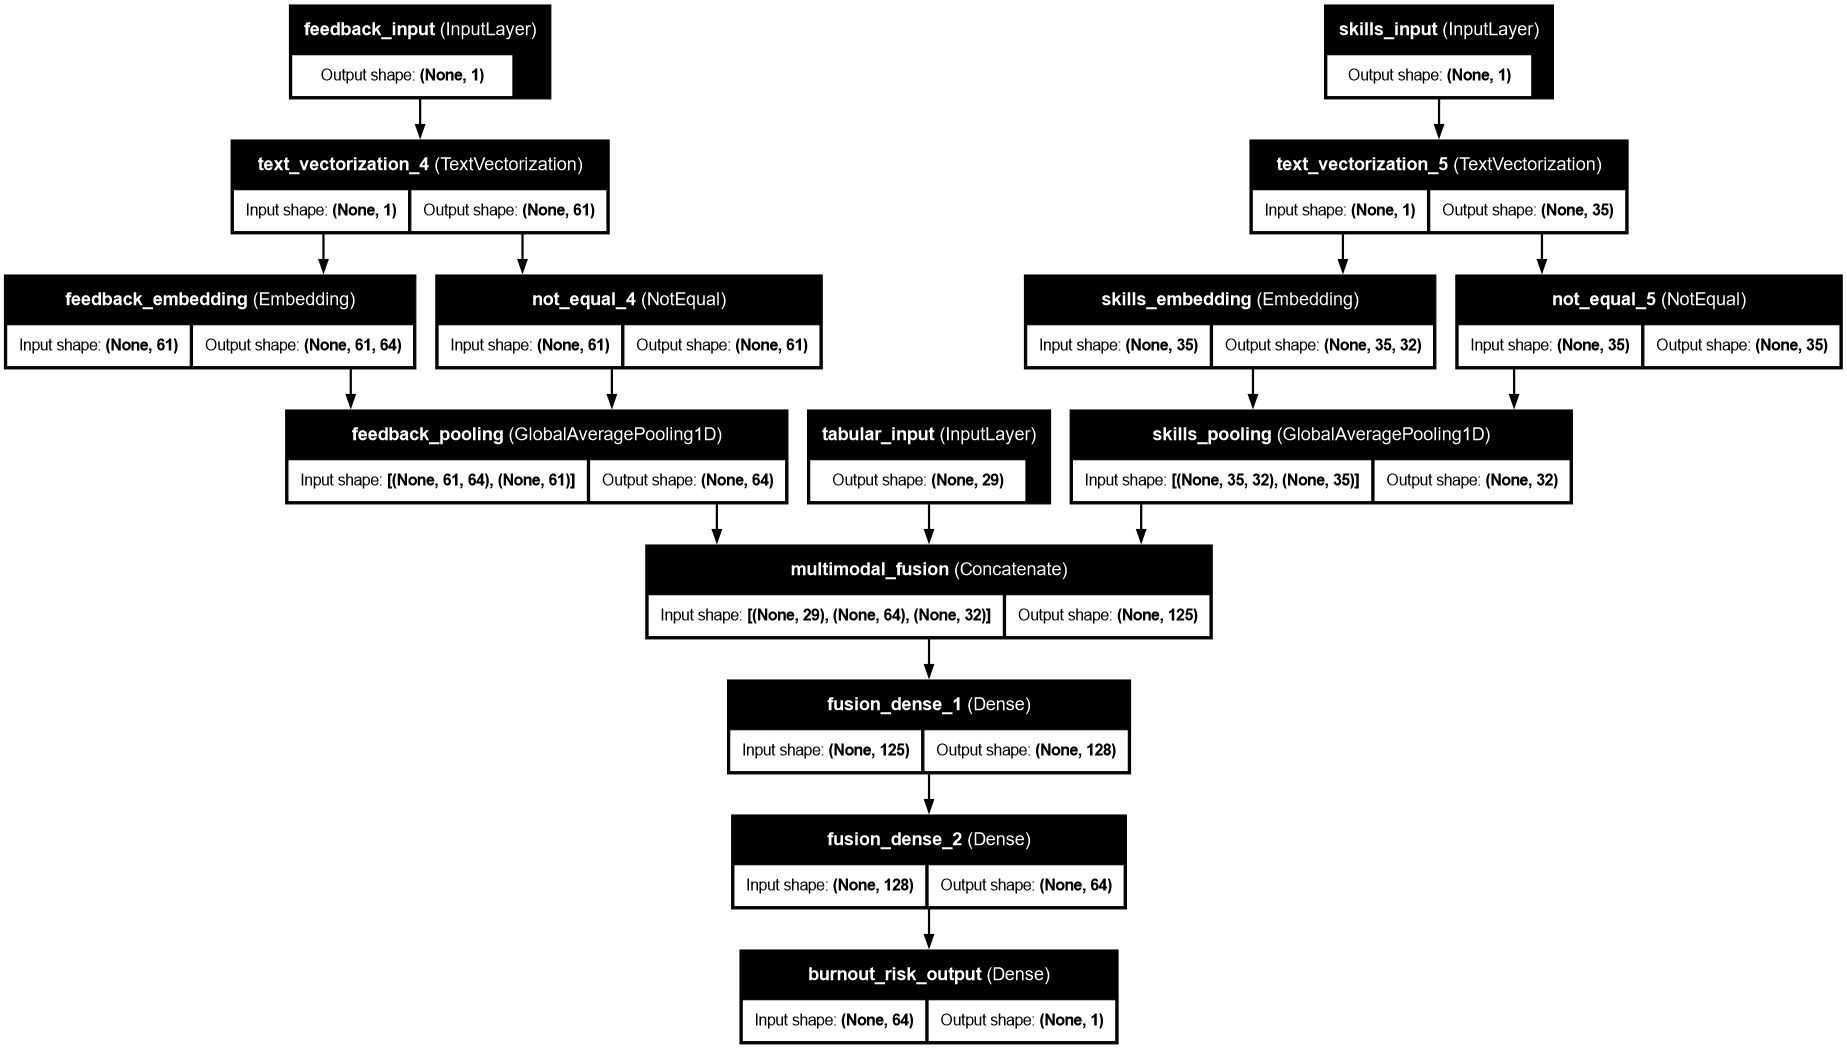

In [102]:
# visualize the model architecture
output_path = Path('asset') / 'burnout_multimodal_fusion_architecture.png'
output_path.parent.mkdir(parents=True, exist_ok=True)

tf.keras.utils.plot_model(
    model_base,
    to_file=str(output_path),
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=80
)

display(Image(filename=str(output_path)))

---
# **Baseline Model Training**
---

Training uses the three prepared inputs together: the tabular matrix, the feedback text branch, and the skill text branch. The goal at this stage is still to establish a stable baseline rather than to perform aggressive hyperparameter tuning.

`EarlyStopping` is included to make the training process more disciplined. Here it monitors `val_loss`, waits for two consecutive epochs without improvement, and then restores the best weights that were seen during training. That setup helps limit unnecessary epochs once validation performance has plateaued. The `epochs=15` setting should therefore be read as an upper bound, not as a requirement that all 15 epochs must always run. `batch_size=32` is kept as a conventional middle-ground choice that is usually stable for this scale of tabular-plus-text training.

In [103]:
# stop training once validation loss stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model_base.fit(
    {
        'tabular_input': x_train_tab,
        'feedback_input': x_train_feedback,
        'skills_input': x_train_skills
    },
    y_train,
    validation_data=(
        {
            'tabular_input': x_val_tab,
            'feedback_input': x_val_feedback,
            'skills_input': x_val_skills
        },
        y_val
    ),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0173 - mae: 0.0829 - val_loss: 9.0652e-04 - val_mae: 0.0229
Epoch 2/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 6.8222e-04 - mae: 0.0197 - val_loss: 3.2926e-04 - val_mae: 0.0142
Epoch 3/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 2.6189e-04 - mae: 0.0121 - val_loss: 2.1194e-04 - val_mae: 0.0105
Epoch 4/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.3520e-04 - mae: 0.0085 - val_loss: 1.2122e-04 - val_mae: 0.0085
Epoch 5/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 9.4208e-05 - mae: 0.0069 - val_loss: 8.2932e-05 - val_mae: 0.0064
Epoch 6/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 8.7506e-05 - mae: 0.0061 - val_loss: 6.1410e-05 - val_mae: 0.0056
Epoch 7/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5.8365e-05 - mae: 0.0050 - val_loss: 3.6618e-05 - val_mae: 0.0044
Epoch 8/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 3.6413e-05 - mae: 0.0041 - val_loss: 2.93

The learning curves below help inspect whether the model is learning smoothly and whether the validation metrics move in the same general direction as the training metrics. A widening gap between training and validation curves would suggest overfitting, while both curves flattening early would suggest that the model is reaching its current capacity.

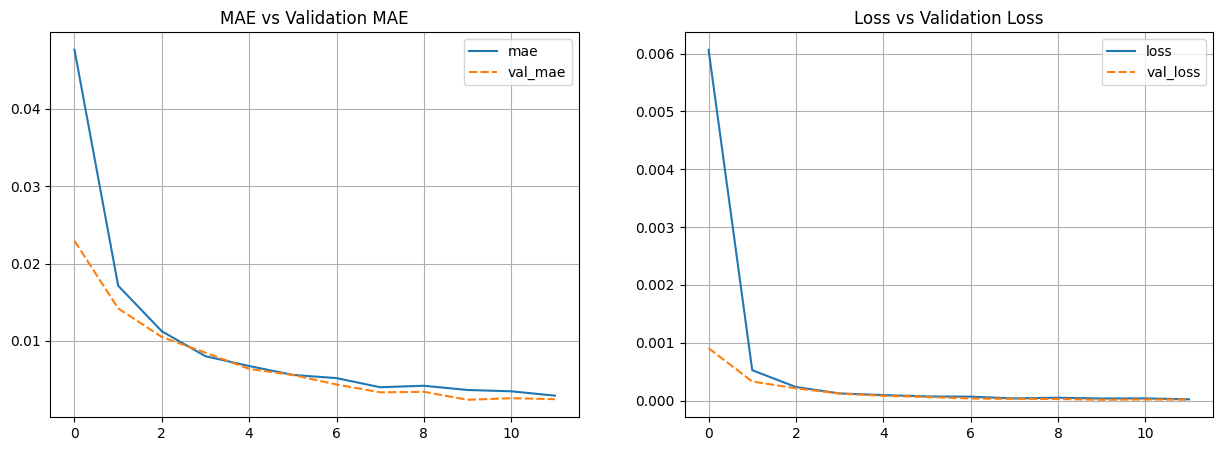

In [104]:
# convert the training history into a dataframe for easier plotting
model_hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(15, 5))

# left panel: absolute error during training and validation
plt.subplot(1, 2, 1)
sns.lineplot(data=model_hist_df[['mae', 'val_mae']])
plt.grid()
plt.title('MAE vs Validation MAE')

# right panel: optimization loss during training and validation
plt.subplot(1, 2, 2)
sns.lineplot(data=model_hist_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Validation Loss')

plt.show()

---
# **Model Testing**
---

The next step is to generate predictions on the held-out test set. This is where the notebook moves from training behavior to unseen-data evaluation. The testing step stays separate so the final metrics reflect model performance on data that was not used to fit the weights or tune the validation behavior.

In [105]:
# generate predictions on the held-out test split
y_pred = model_base.predict({
    'tabular_input': x_test_tab,
    'feedback_input': x_test_feedback,
    'skills_input': x_test_skills
})

y_pred = y_pred.flatten()

500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


---
# **Evaluation**
---

The evaluation block above uses three complementary regression views. `MSE` penalizes large mistakes more strongly, `MAE` shows the average absolute prediction gap in a more interpretable way, and `R-squared` indicates how much variance in the target is explained by the model. The scatter plot is then used as a quick visual check of calibration and spread.

Test MSE: 1.5002076418714579e-05
Test MAE: 0.0024609265866704175
Test R2: 0.9998508946523815


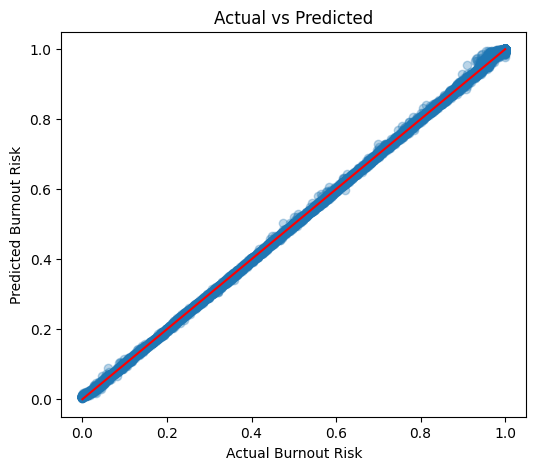

In [106]:
# calculate regression metrics on the test set
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Test MSE:', mse)
print('Test MAE:', mae)
print('Test R2:', r2)

# compare actual and predicted values visually
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, 1], [0, 1], color='red')
plt.xlabel('Actual Burnout Risk')
plt.ylabel('Predicted Burnout Risk')
plt.title('Actual vs Predicted')
plt.show()

WHAT?! The model achieved stunning, almost perfect results!

<img src="https://raw.githubusercontent.com/seankafka/employee-burnout-prediction/refs/heads/main/asset/Thanos-Impossible-meme.jpg" width="50%" />

The model produced extremely strong results on the test set even with a relatively simple baseline architecture. It reached a Test MSE of approximately `0.000015`, a Test MAE of about `0.0025`, and an `R-squared` score close to `0.9999`. The Actual vs Predicted plot also remains almost perfectly aligned with the diagonal line.

These results suggest that the unusually strong performance is likely driven less by model complexity and more by the structure of the dataset itself. This synthetic dataset appears to contain very strong and low-noise relationships between `burnout_risk` and the retained structured variables.

In other words, even after removing target-related features, the remaining predictors still seem to carry enough direct signal for the model to reconstruct the target with very little error.

This also indicates that the text branches are probably not the main reason for the near-perfect performance. The tabular features are likely doing most of the heavy lifting, while the text inputs function more as complementary context than as primary drivers of the prediction.

Because of that, these results should be interpreted carefully. Extremely high predictive performance in this setting does not imply robustness. Real organizational data is usually much noisier and more complex, with measurement inconsistencies, missing information, shifting workplace conditions, and more irregular behavioral patterns than those reflected in this synthetic dataset.

In this project, strengthening reliability and interpretability is more important than trying to improve metrics that are already near the practical ceiling of the dataset, as there is almost no room left for measurable performance gain. A more meaningful next step would be to focus on model stability, robustness towards noise and variance with real-world data. That way an objective interpretability can be seen.

---
# **Conclusion**
---

## **Model Summary**

This notebook built a baseline multimodal model for predicting `burnout_risk` by combining one structured tabular branch with two lightweight text branches. The tabular input was kept in its prepared form, while the feedback and skill text inputs were encoded through `TextVectorization`, `Embedding`, and `GlobalAveragePooling1D` before being fused and passed through shared dense layers.

From a workflow perspective, it is believed the modeling pipeline is now clean and consistent. Features prone to leakage were removed, preprocessing was fitted only on the training split, and the final architecture stayed simple enough to remain explainable while still handling mixed data types in a coherent way.

The final result, however, is that the model achieved extremely high test performance. This suggests that the retained features, especially the structured variables, still contain a very strong signal for reconstructing the target.

Because of that, the most important takeaway from this project is not only that the model works well, but also that this synthetic dataset appears highly structured and unusually easy to learn.

## **Business Recommendation**

From a business point of view, this type of model would be more appropriate as an early warning support tool than as a fully automated decision system. The predicted burnout risk score could help HR teams identify which employee profiles or workforce segments may deserve closer review, especially when high scores appear together with worsening workload, lower satisfaction, or more negative communication patterns.

In practice, the prediction should be treated as a prioritization signal rather than as a final judgment. The most responsible use would be to combine the score with managerial context, employee history, and broader organizational evidence before deciding on any intervention.

This means the strongest business value of the model lies in supporting earlier follow-up, more consistent risk monitoring, and better allocation of employee-support resources. It should help guide attention, not replace human decision-making.

## **Further Improvements**

The most useful next step would be to strengthen validation rather than to chase even smaller error values on the current dataset. Since performance is already near the apparent ceiling of this synthetic data, further work should focus more on robustness, stability, and credibility than on raw metric improvement.

A practical improvement would be to compare this multimodal fusion model against simpler baselines, especially a tabular-only model, to test how much the text branches actually contribute. Repeated runs across different random seeds would also help show whether the training outcome is stable or highly sensitive to initialization.

Beyond that, future work could introduce stronger regularization, more realistic stress-testing with noisy inputs, or richer text encoders if there is clear evidence that the baseline has reached its limit. However, those upgrades would only be meaningful after the current model has been benchmarked more carefully and interpreted in a way that remains honest about the synthetic nature of the dataset.

---
# **Model Saving**
---

In [107]:
# define the artifacts needed again during inference
cat_cols = ['job_level', 'left_company', 'department_group']
num_cols = [
    'tenure_months', 'salary', 'performance_score', 'satisfaction_score',
    'workload_score', 'team_sentiment', 'project_completion_rate',
    'overtime_hours', 'training_participation', 'collaboration_score',
    'email_sentiment', 'role_complexity_score', 'career_progression_score'
]
feedback_col = ['feedback_tokens']
skills_col = ['skillset']

save_dir = Path('model_saving')
save_dir.mkdir(parents=True, exist_ok=True)

In [108]:
# save feature column references for the inference notebook
with open(save_dir / 'list_num_cols.txt', 'w') as file_1:
    json.dump(num_cols, file_1)

with open(save_dir / 'list_cat_cols.txt', 'w') as file_2:
    json.dump(cat_cols, file_2)

with open(save_dir / 'list_feedback_col.txt', 'w') as file_3:
    json.dump(feedback_col, file_3)

with open(save_dir / 'list_skills_tokens.txt', 'w') as file_4:
    json.dump(skills_col, file_4)

# save fitted preprocessing objects for reuse during inference
with open(save_dir / 'scaler.pkl', 'wb') as file_5:
    pickle.dump(scaler, file_5)

with open(save_dir / 'encoder.pkl', 'wb') as file_6:
    pickle.dump(encoder, file_6)

# save the trained multimodal model, including the text vectorization layers inside it
model_base.save(save_dir / 'model_base.keras')

---
# **Model Inference**
---

Inference is handled in a separate notebook, [`3_employee-burnout_inference.ipynb`](3_employee-burnout_inference.ipynb), using the saved column references, preprocessing objects, and trained model exported in the section above.